In [8]:
# ===== STEP 1: install + import =====
import sys
import subprocess

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])

# 安装需要的库
try:
    import requests
    from bs4 import BeautifulSoup
except:
    pip_install("requests", "beautifulsoup4", "lxml")

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
from urllib.parse import urljoin

print("✅ Environment ready")

✅ Environment ready


In [7]:
import sys
!{sys.executable} -m pip install pandas requests beautifulsoup4 lxml

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 585.1 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.9 MB 682.9 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.9 MB 682.9 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/9.9 MB 682.4 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.9 MB 682.4 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.9 MB 718.6 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\16598\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [10]:
# ===== DATASET 3: Architecture Text Dataset - Fixed Version =====

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re
from pathlib import Path

# Output path
OUT_DIR = Path(r"C:\Users\16598\workshop_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUT_DIR / "dataset_3_architecture_text.csv"
json_path = OUT_DIR / "dataset_3_architecture_text.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

# Architecture / spatial keywords
pages = [
    "Arcade_(architecture)",
    "Corridor",
    "Colonnade",
    "Atrium_(architecture)",
    "Portico",
    "Gallery_(architecture)",
    "Alley",
    "Passage_(architecture)",
    "Threshold_(architecture)",
    "Courtyard",
    "Cloister",
    "Vault_(architecture)",
    "Arch",
    "Nave",
    "Aisle",
    "Loggia",
    "Piazza",
    "Urban_design",
    "Interior_architecture",
    "Spatial_design",
    "Public_space",
    "Circulation_(architecture)",
    "Wayfinding",
    "Promenade_architecturale",
    "Phenomenology_(architecture)"
]

def clean_text(text):
    text = re.sub(r"\[[0-9]+\]", "", text)   # remove wikipedia refs like [1]
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def split_into_chunks(text, page, url):
    # Split by sentence, then group 2 sentences as one sample
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks = []
    
    buffer = []
    for s in sentences:
        s = clean_text(s)
        if len(s) < 40:
            continue
        buffer.append(s)
        
        if len(buffer) >= 2:
            chunk = " ".join(buffer)
            if 120 <= len(chunk) <= 900:
                chunks.append({
                    "source": "Wikipedia",
                    "page": page,
                    "url": url,
                    "text": chunk,
                    "word_count": len(chunk.split())
                })
            buffer = []
    
    return chunks

all_data = []

for page in pages:
    url = "https://en.wikipedia.org/wiki/" + page
    print("Scraping:", url)
    
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print("  skipped, status:", r.status_code)
            continue
        
        # IMPORTANT: use html.parser, not lxml
        soup = BeautifulSoup(r.text, "html.parser")
        
        paragraphs = soup.select("p")
        full_text = ""
        
        for p in paragraphs:
            txt = clean_text(p.get_text(" ", strip=True))
            if len(txt) > 80:
                full_text += txt + " "
        
        chunks = split_into_chunks(full_text, page, url)
        all_data.extend(chunks)
        
        print("  chunks:", len(chunks))
        time.sleep(random.uniform(0.5, 1.2))
        
    except Exception as e:
        print("  error:", e)

df = pd.DataFrame(all_data)

# If too many, keep first 300
if len(df) > 300:
    df = df.head(300)

df.to_csv(csv_path, index=False, encoding="utf-8-sig")
df.to_json(json_path, orient="records", force_ascii=False, indent=2)

print("\n✅ DONE")
print("Total samples:", len(df))
print("CSV saved to :", csv_path)
print("JSON saved to:", json_path)

df.head(10)

Scraping: https://en.wikipedia.org/wiki/Arcade_(architecture)
  skipped, status: 403
Scraping: https://en.wikipedia.org/wiki/Corridor
  skipped, status: 403
Scraping: https://en.wikipedia.org/wiki/Colonnade
  chunks: 7
Scraping: https://en.wikipedia.org/wiki/Atrium_(architecture)
  chunks: 13
Scraping: https://en.wikipedia.org/wiki/Portico
  chunks: 12
Scraping: https://en.wikipedia.org/wiki/Gallery_(architecture)
  skipped, status: 403
Scraping: https://en.wikipedia.org/wiki/Alley
  chunks: 143
Scraping: https://en.wikipedia.org/wiki/Passage_(architecture)
  skipped, status: 403
Scraping: https://en.wikipedia.org/wiki/Threshold_(architecture)
  skipped, status: 403
Scraping: https://en.wikipedia.org/wiki/Courtyard
  chunks: 26
Scraping: https://en.wikipedia.org/wiki/Cloister
  chunks: 8
Scraping: https://en.wikipedia.org/wiki/Vault_(architecture)
  chunks: 73
Scraping: https://en.wikipedia.org/wiki/Arch
  chunks: 116
Scraping: https://en.wikipedia.org/wiki/Nave
  chunks: 9
Scraping: h

,source,page,url,text,word_count
0,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,"In classical architecture , a colonnade is a l...",45
1,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,The space enclosed may be covered or open. Pet...,21
2,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,"When in front of a building, screening the doo...",26
3,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,A portico may be more than one rank of columns...,39
4,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,"αραιος, ""widely spaced"", and συστυλος, ""with c...",62
5,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,"[ 3 ] At the British Museum , for example, por...",31
6,Wikipedia,Colonnade,https://en.wikipedia.org/wiki/Colonnade,", (in style a peripteral classical temple) can...",49
7,Wikipedia,Atrium_(architecture),https://en.wikipedia.org/wiki/Atrium_(architec...,: atria or atriums) [ 1 ] is a large open-air ...,41
8,Wikipedia,Atrium_(architecture),https://en.wikipedia.org/wiki/Atrium_(architec...,"Modern atria, as developed in the late 19th an...",71
9,Wikipedia,Atrium_(architecture),https://en.wikipedia.org/wiki/Atrium_(architec...,"[ 4 ] Atria are popular with building users, b...",40


In [ ]:
# ===== DATASET 2: Generate captions for film frames using BLIP =====

import sys
import subprocess
from pathlib import Path
import pandas as pd
from PIL import Image

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])

# Install required packages
try:
    import torch
    from transformers import BlipProcessor, BlipForConditionalGeneration
except:
    pip_install("torch", "torchvision", "transformers", "pillow", "pandas")
    import torch
    from transformers import BlipProcessor, BlipForConditionalGeneration

# Your image dataset path
IMG_DIR = Path(r"C:\Users\16598\workshop1_output\images\dataset_200")

# Output folder
OUT_DIR = Path(r"C:\Users\16598\workshop_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUT_DIR / "dataset_2_film_frame_captions.csv"

# Collect images
image_paths = sorted(
    list(IMG_DIR.glob("*.jpg")) +
    list(IMG_DIR.glob("*.png")) +
    list(IMG_DIR.glob("*.webp"))
)

print("Images found:", len(image_paths))
print("First image:", image_paths[0] if image_paths else "None")

# Load BLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.to(device)

records = []

for i, img_path in enumerate(image_paths):
    try:
        image = Image.open(img_path).convert("RGB")

        inputs = processor(image, return_tensors="pt").to(device)

        output = model.generate(
            **inputs,
            max_new_tokens=40
        )

        caption = processor.decode(output[0], skip_special_tokens=True)

        records.append({
            "image_id": img_path.stem,
            "image_path": str(img_path),
            "caption": caption
        })

        if (i + 1) % 25 == 0:
            print(f"Processed {i+1}/{len(image_paths)}")

    except Exception as e:
        print("Error with", img_path.name, e)

df_caption = pd.DataFrame(records)
df_caption.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("\n✅ DONE")
print("Captions generated:", len(df_caption))
print("Saved to:", csv_path)

df_caption.head(10)

In [2]:
from pathlib import Path
import pandas as pd

manifest_path = Path(r"C:\Users\16598\workshop2_part2_yolo\manifest.csv")

print("File exists:", manifest_path.exists())
print("Path:", manifest_path)

if manifest_path.exists():
    df_yolo = pd.read_csv(manifest_path)
    print("Rows:", len(df_yolo))
    display(df_yolo.head(10))

File exists: True
Path: C:\Users\16598\workshop2_part2_yolo\manifest.csv
Rows: 162


,source_image,obj_id,class,class_id,conf,x1,y1,x2,y2,mask_path,crop_path,annotated_path
0,poc_00001.jpg,0,chair,56,0.893652,170,536,300,707,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
1,poc_00001.jpg,1,chair,56,0.875297,1087,466,1279,718,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
2,poc_00001.jpg,2,chair,56,0.736624,871,360,968,514,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
3,poc_00001.jpg,3,chair,56,0.720254,603,385,713,611,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
4,poc_00001.jpg,4,dining table,60,0.656231,0,578,258,709,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
5,poc_00001.jpg,5,chair,56,0.583012,1198,425,1278,470,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
6,poc_00001.jpg,6,chair,56,0.573488,1030,361,1119,488,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
7,poc_00001.jpg,7,dining table,60,0.526552,879,361,1110,513,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
8,poc_00001.jpg,8,chair,56,0.454227,970,262,1031,368,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
9,poc_00001.jpg,9,chair,56,0.351727,814,327,894,469,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...


In [3]:
# ===== CLEAN DATASET 2: YOLO spatial element dataset =====

from pathlib import Path
import pandas as pd

manifest_path = Path(r"C:\Users\16598\workshop2_part2_yolo\manifest.csv")

OUT_DIR = Path(r"C:\Users\16598\workshop_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_csv = OUT_DIR / "dataset_2_yolo_spatial_elements_clean.csv"

df_yolo = pd.read_csv(manifest_path)

# Calculate bbox width, height, area and centre point
df_yolo["width"] = df_yolo["x2"] - df_yolo["x1"]
df_yolo["height"] = df_yolo["y2"] - df_yolo["y1"]
df_yolo["area"] = df_yolo["width"] * df_yolo["height"]
df_yolo["center_x"] = (df_yolo["x1"] + df_yolo["x2"]) / 2
df_yolo["center_y"] = (df_yolo["y1"] + df_yolo["y2"]) / 2

# Rename class column to spatial_element
df_clean = df_yolo.rename(columns={"class": "spatial_element"})

# Keep useful columns
keep_cols = [
    "source_image",
    "obj_id",
    "spatial_element",
    "conf",
    "x1", "y1", "x2", "y2",
    "width", "height", "area",
    "center_x", "center_y",
    "mask_path", "crop_path", "annotated_path"
]

df_clean = df_clean[keep_cols]

df_clean.to_csv(out_csv, index=False, encoding="utf-8-sig")

print("✅ Dataset 2 cleaned")
print("Rows:", len(df_clean))
print("Saved to:", out_csv)

print("\nElement counts:")
display(df_clean["spatial_element"].value_counts())

df_clean.head(10)

✅ Dataset 2 cleaned
Rows: 162
Saved to: C:\Users\16598\workshop_final\dataset_2_yolo_spatial_elements_clean.csv

Element counts:


spatial_element
chair           40
handbag         31
bench           24
potted plant    23
suitcase        14
backpack         8
dining table     7
clock            5
bottle           5
vase             2
couch            1
laptop           1
cell phone       1
Name: count, dtype: int64

,source_image,obj_id,spatial_element,conf,x1,y1,x2,y2,width,height,area,center_x,center_y,mask_path,crop_path,annotated_path
0,poc_00001.jpg,0,chair,0.893652,170,536,300,707,130,171,22230,235.0,621.5,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
1,poc_00001.jpg,1,chair,0.875297,1087,466,1279,718,192,252,48384,1183.0,592.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
2,poc_00001.jpg,2,chair,0.736624,871,360,968,514,97,154,14938,919.5,437.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
3,poc_00001.jpg,3,chair,0.720254,603,385,713,611,110,226,24860,658.0,498.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
4,poc_00001.jpg,4,dining table,0.656231,0,578,258,709,258,131,33798,129.0,643.5,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
5,poc_00001.jpg,5,chair,0.583012,1198,425,1278,470,80,45,3600,1238.0,447.5,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
6,poc_00001.jpg,6,chair,0.573488,1030,361,1119,488,89,127,11303,1074.5,424.5,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
7,poc_00001.jpg,7,dining table,0.526552,879,361,1110,513,231,152,35112,994.5,437.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
8,poc_00001.jpg,8,chair,0.454227,970,262,1031,368,61,106,6466,1000.5,315.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...
9,poc_00001.jpg,9,chair,0.351727,814,327,894,469,80,142,11360,854.0,398.0,C:\Users\16598\workshop2_part2_yolo\masks\poc_...,C:\Users\16598\workshop2_part2_yolo\crops\poc_...,C:\Users\16598\workshop2_part2_yolo\annotated\...


In [4]:
# ===== STEP 4: Prepare text for vectorisation =====

import pandas as pd

# Load datasets
df_text = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_3_architecture_text.csv")
df_yolo = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_2_yolo_spatial_elements_clean.csv")

print("Text samples:", len(df_text))
print("YOLO elements:", len(df_yolo))

# Create simplified text corpus
text_corpus = df_text["text"].tolist()

# Convert YOLO classes into "spatial descriptions"
yolo_texts = df_yolo["spatial_element"].astype(str).tolist()

# Merge into one dataset
combined_text = text_corpus + yolo_texts

print("Total combined samples:", len(combined_text))
print("Example:")
print(combined_text[:10])

Text samples: 300
YOLO elements: 162
Total combined samples: 462
Example:
['In classical architecture , a colonnade is a long sequence of columns joined by their entablature , often free-standing, or part of a building. [ 1 ] Paired or multiple pairs of columns are normally employed in a colonnade which can be straight or curved.', "The space enclosed may be covered or open. Peter's Square in Rome, Bernini's great colonnade encloses a vast open elliptical space.", 'When in front of a building, screening the door (Latin porta ), it is called a portico . When enclosing an open court, a peristyle .', 'A portico may be more than one rank of columns deep, as at the Pantheon in Rome or the stoae of Ancient Greece . When the intercolumniation is alternately wide and narrow, a colonnade may be termed "araeosystyle" (Gr.', 'αραιος, "widely spaced", and συστυλος, "with columns set close together"), as in the case of the western porch of St Paul\'s Cathedral and the east front of the Louvre . [ 2

In [7]:
# ===== STEP 5: TF-IDF Vectorisation + Similarity =====

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Load datasets again
df_text = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_3_architecture_text.csv")
df_yolo = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_2_yolo_spatial_elements_clean.csv")

# --- Prepare text ---

# Architecture descriptions
arch_texts = df_text["text"].tolist()

# YOLO spatial elements → turn into phrases
yolo_texts = ["a space with " + str(x) for x in df_yolo["spatial_element"]]

# Combine
all_texts = arch_texts + yolo_texts

print("Architecture texts:", len(arch_texts))
print("YOLO texts:", len(yolo_texts))

# --- Vectorise ---
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Split back
arch_vectors = tfidf_matrix[:len(arch_texts)]
yolo_vectors = tfidf_matrix[len(arch_texts):]

# --- Compute similarity ---
similarity = cosine_similarity(yolo_vectors, arch_vectors)

print("Similarity matrix shape:", similarity.shape)

# --- Find best match ---
results = []

for i, row in enumerate(similarity):
    best_idx = row.argmax()
    
    results.append({
        "yolo_element": df_yolo.iloc[i]["spatial_element"],
        "matched_arch_text": df_text.iloc[best_idx]["text"],
        "similarity_score": row.max()
    })

df_match = pd.DataFrame(results)

# Save results
out_path = r"C:\Users\16598\workshop_final\dataset_4_spatial_matching.csv"
df_match.to_csv(out_path, index=False, encoding="utf-8-sig")

print("\n✅ DONE")
print("Saved to:", out_path)

df_match.head(10)

Architecture texts: 300
YOLO texts: 162
Similarity matrix shape: (162, 300)

✅ DONE
Saved to: C:\Users\16598\workshop_final\dataset_4_spatial_matching.csv


,yolo_element,matched_arch_text,similarity_score
0,chair,"With space at a premium, architects are experi...",0.141262
1,chair,"With space at a premium, architects are experi...",0.141262
2,chair,"With space at a premium, architects are experi...",0.141262
3,chair,"With space at a premium, architects are experi...",0.141262
4,dining table,In a more contemporary version of the Chinese ...,0.119088
5,chair,"With space at a premium, architects are experi...",0.141262
6,chair,"With space at a premium, architects are experi...",0.141262
7,dining table,In a more contemporary version of the Chinese ...,0.119088
8,chair,"With space at a premium, architects are experi...",0.141262
9,chair,"With space at a premium, architects are experi...",0.141262


In [6]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.7 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 6.0 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 5.9 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.1 MB/s  0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\16598\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [8]:
# ===== STEP 6: Improved spatial interpretation + TF-IDF matching =====

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_text = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_3_architecture_text.csv")
df_yolo = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_2_yolo_spatial_elements_clean.csv")

# Translate YOLO object labels into spatial meanings
spatial_meaning = {
    "chair": "seating area resting zone human occupation interior furniture pause space",
    "bench": "public sitting area transitional space waiting zone urban furniture",
    "potted plant": "soft boundary interior landscape natural edge spatial atmosphere",
    "dining table": "gathering space social centre shared surface communal occupation",
    "handbag": "human presence temporary occupation personal object movement trace",
    "suitcase": "movement transition travel threshold temporary occupation",
    "backpack": "human presence mobility informal occupation",
    "clock": "temporal marker rhythm waiting spatial orientation",
    "bottle": "small object human occupation social use",
    "vase": "decorative object interior atmosphere spatial ornament",
    "couch": "resting zone domestic interior soft occupation",
    "laptop": "work surface digital occupation interior activity",
    "cell phone": "human presence communication temporary attention"
}

df_yolo["spatial_description"] = df_yolo["spatial_element"].map(spatial_meaning).fillna(
    df_yolo["spatial_element"].astype(str)
)

arch_texts = df_text["text"].astype(str).tolist()
yolo_texts = df_yolo["spatial_description"].astype(str).tolist()

all_texts = arch_texts + yolo_texts

vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(all_texts)

arch_vectors = tfidf_matrix[:len(arch_texts)]
yolo_vectors = tfidf_matrix[len(arch_texts):]

similarity = cosine_similarity(yolo_vectors, arch_vectors)

results = []

for i, row in enumerate(similarity):
    best_idx = row.argmax()
    results.append({
        "source_image": df_yolo.iloc[i]["source_image"],
        "yolo_element": df_yolo.iloc[i]["spatial_element"],
        "spatial_description": df_yolo.iloc[i]["spatial_description"],
        "matched_arch_page": df_text.iloc[best_idx]["page"],
        "matched_arch_text": df_text.iloc[best_idx]["text"],
        "similarity_score": row.max()
    })

df_match_improved = pd.DataFrame(results)

out_path = r"C:\Users\16598\workshop_final\dataset_4_spatial_matching_improved.csv"
df_match_improved.to_csv(out_path, index=False, encoding="utf-8-sig")

print("✅ Improved spatial matching done")
print("Saved to:", out_path)
print("Average similarity:", df_match_improved["similarity_score"].mean())
print("Max similarity:", df_match_improved["similarity_score"].max())

df_match_improved.head(10)

✅ Improved spatial matching done
Saved to: C:\Users\16598\workshop_final\dataset_4_spatial_matching_improved.csv
Average similarity: 0.09005441557593548
Max similarity: 0.1522390834879528


,source_image,yolo_element,spatial_description,matched_arch_page,matched_arch_text,similarity_score
0,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
1,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
2,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
3,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
4,poc_00001.jpg,dining table,gathering space social centre shared surface c...,Courtyard,"With space at a premium, architects are experi...",0.152239
5,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
6,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
7,poc_00001.jpg,dining table,gathering space social centre shared surface c...,Courtyard,"With space at a premium, architects are experi...",0.152239
8,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407
9,poc_00001.jpg,chair,seating area resting zone human occupation int...,Courtyard,"With space at a premium, architects are experi...",0.107407


In [9]:
# ===== STEP 7: Analysis =====

import pandas as pd

df = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_4_spatial_matching_improved.csv")

print("Total matches:", len(df))

# 1. 哪些空间元素最多？
print("\nTop spatial elements:")
print(df["yolo_element"].value_counts())

# 2. 哪些建筑页面被匹配最多？
print("\nTop matched architecture pages:")
print(df["matched_arch_page"].value_counts())

# 3. 平均相似度按元素
print("\nAverage similarity by element:")
print(df.groupby("yolo_element")["similarity_score"].mean().sort_values(ascending=False))

Total matches: 162

Top spatial elements:
yolo_element
chair           40
handbag         31
bench           24
potted plant    23
suitcase        14
backpack         8
dining table     7
clock            5
bottle           5
vase             2
couch            1
laptop           1
cell phone       1
Name: count, dtype: int64

Top matched architecture pages:
matched_arch_page
Courtyard                93
Alley                    66
Arch                      2
Atrium_(architecture)     1
Name: count, dtype: int64

Average similarity by element:
yolo_element
dining table    0.152239
bottle          0.146482
couch           0.142464
cell phone      0.108832
chair           0.107407
vase            0.106271
bench           0.100148
laptop          0.095465
suitcase        0.086696
potted plant    0.084410
handbag         0.062040
clock           0.035990
backpack        0.034153
Name: similarity_score, dtype: float64


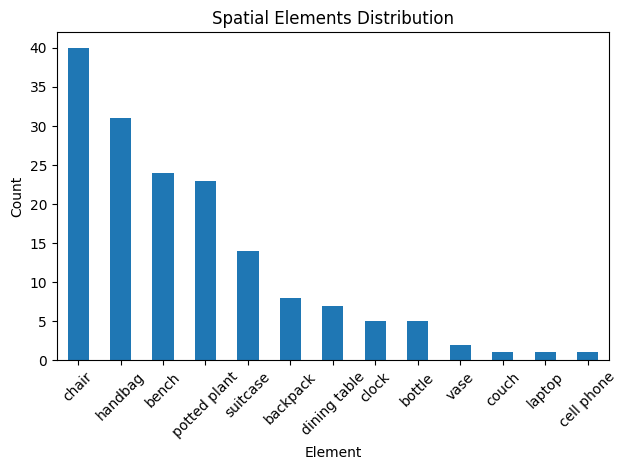

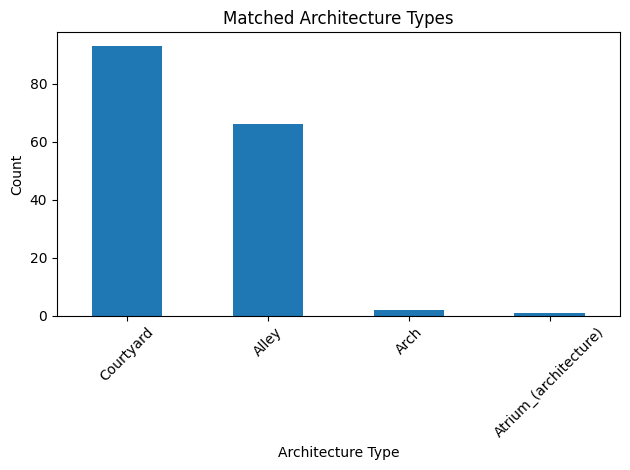

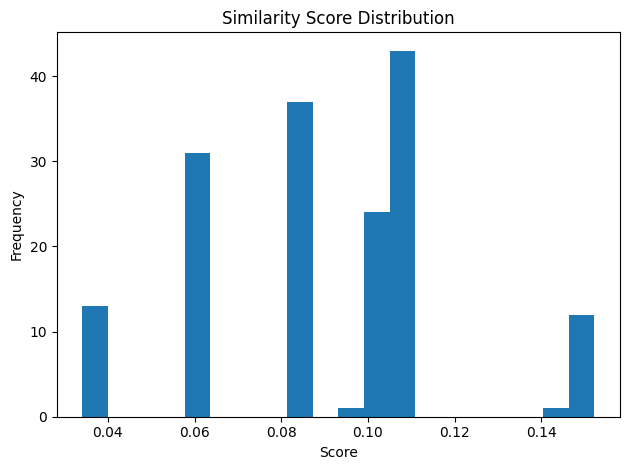

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\16598\workshop_final\dataset_4_spatial_matching_improved.csv")

# ===== 图1：空间元素分布 =====
plt.figure()
df["yolo_element"].value_counts().plot(kind="bar")
plt.title("Spatial Elements Distribution")
plt.xlabel("Element")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== 图2：建筑空间匹配分布 =====
plt.figure()
df["matched_arch_page"].value_counts().plot(kind="bar")
plt.title("Matched Architecture Types")
plt.xlabel("Architecture Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ===== 图3：相似度分布 =====
plt.figure()
plt.hist(df["similarity_score"], bins=20)
plt.title("Similarity Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
# ===== DATASET 4: Architecture Treatise Text Dataset from Project Gutenberg =====

import requests
import pandas as pd
import re
import time
from pathlib import Path

OUT_DIR = Path(r"C:\Users\16598\workshop_final")
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_path = OUT_DIR / "dataset_4_architecture_treatise_text.csv"
json_path = OUT_DIR / "dataset_4_architecture_treatise_text.json"

HEADERS = {
    "User-Agent": "Mozilla/5.0"
}

# Public Project Gutenberg texts / pages
# Vitruvius text URL is direct .txt.
# Ruskin pages are HTML, so we strip tags after download.
sources = [
    {
        "source": "Project Gutenberg",
        "title": "The Ten Books on Architecture",
        "author": "Vitruvius Pollio",
        "url": "https://www.gutenberg.org/files/20239/20239.txt",
        "type": "txt"
    },
    {
        "source": "Project Gutenberg",
        "title": "The Seven Lamps of Architecture",
        "author": "John Ruskin",
        "url": "https://www.gutenberg.org/files/35898/35898-h/35898-h.htm",
        "type": "html"
    },
    {
        "source": "Project Gutenberg",
        "title": "The Stones of Venice, Volume I",
        "author": "John Ruskin",
        "url": "https://www.gutenberg.org/files/30754/30754-h/30754-h.htm",
        "type": "html"
    }
]

def clean_text(text):
    text = re.sub(r"\r", " ", text)
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\[[0-9]+\]", "", text)
    return text.strip()

def strip_html(html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer"]):
        tag.decompose()
    return soup.get_text(" ")

def remove_gutenberg_boilerplate(text):
    # roughly remove Project Gutenberg header/footer
    start_markers = [
        "*** START OF THE PROJECT GUTENBERG EBOOK",
        "*** START OF THIS PROJECT GUTENBERG EBOOK"
    ]
    end_markers = [
        "*** END OF THE PROJECT GUTENBERG EBOOK",
        "*** END OF THIS PROJECT GUTENBERG EBOOK"
    ]

    upper = text.upper()

    start_idx = 0
    for marker in start_markers:
        idx = upper.find(marker)
        if idx != -1:
            # move beyond marker line
            start_idx = idx + len(marker)
            break

    end_idx = len(text)
    for marker in end_markers:
        idx = upper.find(marker)
        if idx != -1:
            end_idx = idx
            break

    return text[start_idx:end_idx]

def split_into_chunks(text, source_info, max_chunks=120):
    # Split by sentences and group 2–3 sentences per sample
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks = []
    buffer = []

    for sentence in sentences:
        sentence = clean_text(sentence)
        if len(sentence) < 60:
            continue

        # keep architecture-related sentences more often
        keywords = [
            "architecture", "building", "space", "wall", "column", "arch",
            "court", "courtyard", "passage", "street", "city", "structure",
            "ornament", "proportion", "temple", "house", "stone", "light",
            "form", "design"
        ]

        if not any(k in sentence.lower() for k in keywords):
            continue

        buffer.append(sentence)

        if len(buffer) >= 2:
            chunk = " ".join(buffer)
            if 180 <= len(chunk) <= 1200:
                chunks.append({
                    "dataset": "architecture_treatise_text",
                    "source": source_info["source"],
                    "title": source_info["title"],
                    "author": source_info["author"],
                    "url": source_info["url"],
                    "text": chunk,
                    "word_count": len(chunk.split())
                })
            buffer = []

        if len(chunks) >= max_chunks:
            break

    return chunks

all_records = []

for src in sources:
    print("Downloading:", src["title"])
    try:
        r = requests.get(src["url"], headers=HEADERS, timeout=30)
        r.raise_for_status()

        raw = r.text

        if src["type"] == "html":
            raw = strip_html(raw)

        raw = remove_gutenberg_boilerplate(raw)
        raw = clean_text(raw)

        chunks = split_into_chunks(raw, src, max_chunks=120)
        all_records.extend(chunks)

        print("  chunks:", len(chunks))
        time.sleep(1)

    except Exception as e:
        print("  error:", e)

df_treatise = pd.DataFrame(all_records)

# Keep 300 samples max, matching the assignment scale
if len(df_treatise) > 300:
    df_treatise = df_treatise.head(300)

df_treatise.to_csv(csv_path, index=False, encoding="utf-8-sig")
df_treatise.to_json(json_path, orient="records", force_ascii=False, indent=2)

print("\n✅ DONE")
print("Total samples:", len(df_treatise))
print("CSV saved to :", csv_path)
print("JSON saved to:", json_path)

df_treatise.head(10)

Downloading: The Ten Books on Architecture
  chunks: 120
Downloading: The Seven Lamps of Architecture
  chunks: 120
Downloading: The Stones of Venice, Volume I
  chunks: 120

✅ DONE
Total samples: 300
CSV saved to : C:\Users\16598\workshop_final\dataset_4_architecture_treatise_text.csv
JSON saved to: C:\Users\16598\workshop_final\dataset_4_architecture_treatise_text.json


,dataset,source,title,author,url,text,word_count
0,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,TEN BOOKS ON ARCHITECTURE *** Produced by Chuc...,56
1,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,PROFESSOR OF ARCHITECTURE IN HARVARD UNIVERSIT...,124
2,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,The suggestions for illustrations in the later...,91
3,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,"He avoids periodic sentences, uses only the si...",63
4,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,But when I saw that you were giving your atten...,164
5,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,"I have drawn up definite rules to enable you, ...",67
6,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,Practice is the continuous and regular exercis...,46
7,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,"It follows, therefore, that architects who hav...",67
8,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,"It appears, then, that one who professes himse...",36
9,architecture_treatise_text,Project Gutenberg,The Ten Books on Architecture,Vitruvius Pollio,https://www.gutenberg.org/files/20239/20239.txt,"Geometry, also, is of much assistance in archi...",63


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import re

out_dir = Path(r"C:\Users\16598\workshop_final\part1_analysis_figures")
out_dir.mkdir(exist_ok=True)

yolo_csv = Path(r"C:\Users\16598\workshop_final\dataset_2_yolo_spatial_elements_clean.csv")
match_csv = Path(r"C:\Users\16598\workshop_final\dataset_4_spatial_matching_improved.csv")
text_csv = Path(r"C:\Users\16598\workshop_final\dataset_4_architecture_treatise_text.csv")

df_yolo = pd.read_csv(yolo_csv)
df_match = pd.read_csv(match_csv)
df_text = pd.read_csv(text_csv)

print("YOLO dataset:", df_yolo.shape)
print("Matching dataset:", df_match.shape)
print("Text dataset:", df_text.shape)

print(df_yolo.columns)
print(df_match.columns)
print(df_text.columns)

YOLO dataset: (162, 16)
Matching dataset: (162, 6)
Text dataset: (300, 7)
Index(['source_image', 'obj_id', 'spatial_element', 'conf', 'x1', 'y1', 'x2',
       'y2', 'width', 'height', 'area', 'center_x', 'center_y', 'mask_path',
       'crop_path', 'annotated_path'],
      dtype='str')
Index(['source_image', 'yolo_element', 'spatial_description',
       'matched_arch_page', 'matched_arch_text', 'similarity_score'],
      dtype='str')
Index(['dataset', 'source', 'title', 'author', 'url', 'text', 'word_count'], dtype='str')


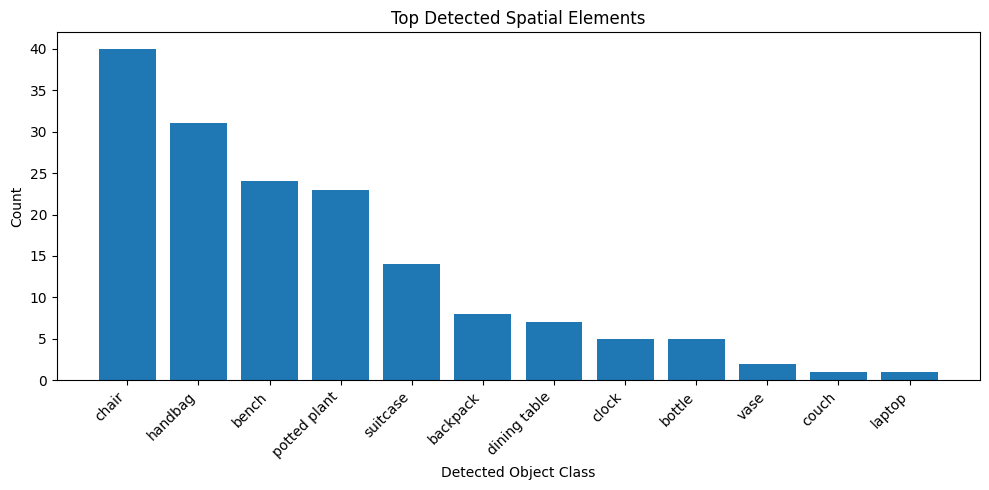

In [2]:
col = "spatial_element" if "spatial_element" in df_yolo.columns else "yolo_element"

counts = df_yolo[col].value_counts().head(12)

plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top Detected Spatial Elements")
plt.xlabel("Detected Object Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "01_object_frequency.png", dpi=300)
plt.show()

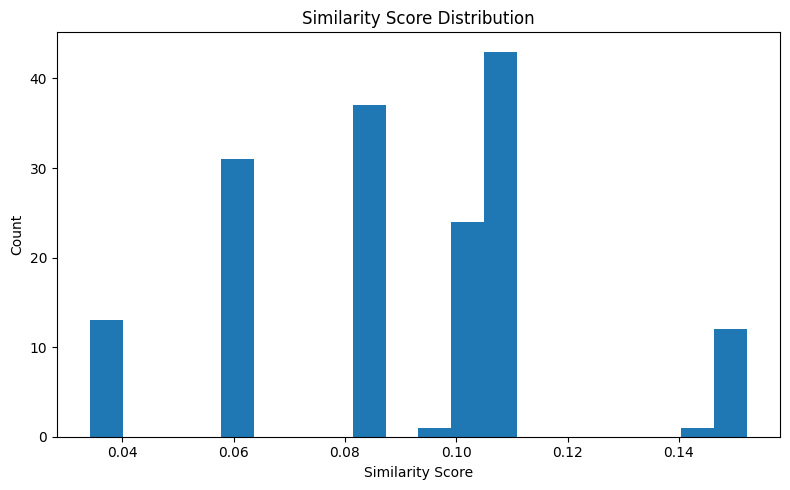

In [3]:
score_col = "similarity_score" if "similarity_score" in df_match.columns else "conf"

scores = pd.to_numeric(df_match[score_col], errors="coerce").dropna()

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=20)
plt.title("Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(out_dir / "02_similarity_distribution.png", dpi=300)
plt.show()

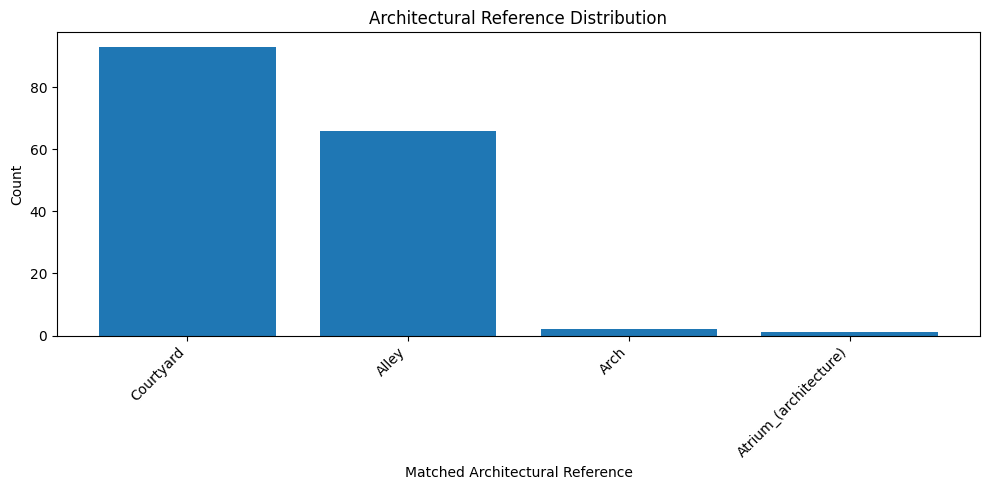

In [4]:
page_col = "matched_arch_page"

if page_col in df_match.columns:
    page_counts = df_match[page_col].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    plt.bar(page_counts.index, page_counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Architectural Reference Distribution")
    plt.xlabel("Matched Architectural Reference")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(out_dir / "03_arch_reference_distribution.png", dpi=300)
    plt.show()
else:
    print("No matched_arch_page column found.")

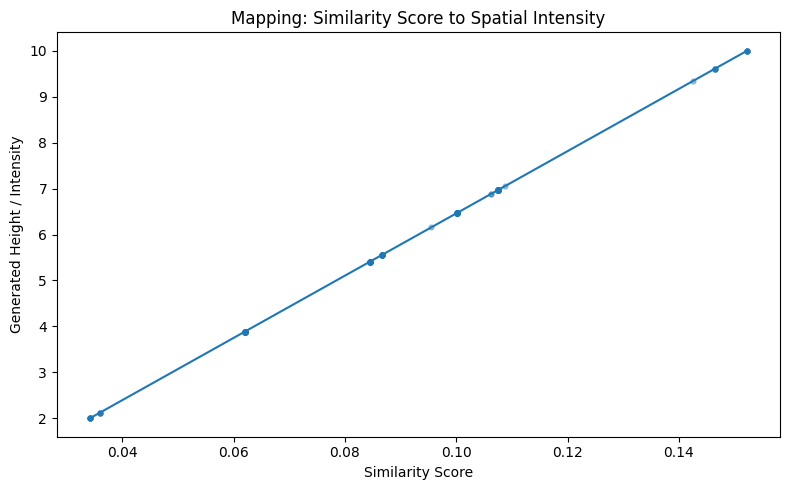

In [5]:
x = np.linspace(scores.min(), scores.max(), 100)
height = np.interp(x, (scores.min(), scores.max()), (2, 10))

plt.figure(figsize=(8, 5))
plt.plot(x, height)
plt.scatter(scores, np.interp(scores, (scores.min(), scores.max()), (2, 10)), s=12, alpha=0.4)
plt.title("Mapping: Similarity Score to Spatial Intensity")
plt.xlabel("Similarity Score")
plt.ylabel("Generated Height / Intensity")
plt.tight_layout()
plt.savefig(out_dir / "04_similarity_to_height_mapping.png", dpi=300)
plt.show()

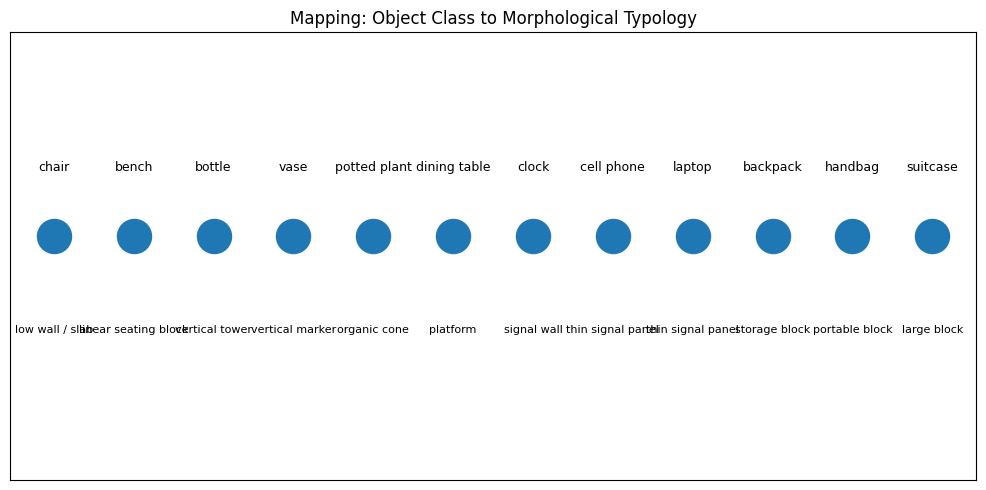

In [6]:
mapping = {
    "chair": "low wall / slab",
    "bench": "linear seating block",
    "bottle": "vertical tower",
    "vase": "vertical marker",
    "potted plant": "organic cone",
    "dining table": "platform",
    "clock": "signal wall",
    "cell phone": "thin signal panel",
    "laptop": "thin signal panel",
    "backpack": "storage block",
    "handbag": "portable block",
    "suitcase": "large block"
}

existing = [k for k in mapping.keys() if k in df_yolo[col].astype(str).unique()]
if len(existing) == 0:
    existing = list(mapping.keys())[:8]

labels = existing
values = list(range(len(labels)))

plt.figure(figsize=(10, 5))
plt.scatter(values, [1]*len(values), s=600)
for i, label in enumerate(labels):
    plt.text(i, 1.08, label, ha="center", fontsize=9)
    plt.text(i, 0.88, mapping[label], ha="center", fontsize=8)
plt.ylim(0.7, 1.25)
plt.xticks([])
plt.yticks([])
plt.title("Mapping: Object Class to Morphological Typology")
plt.tight_layout()
plt.savefig(out_dir / "05_object_to_morphology_mapping.png", dpi=300)
plt.show()

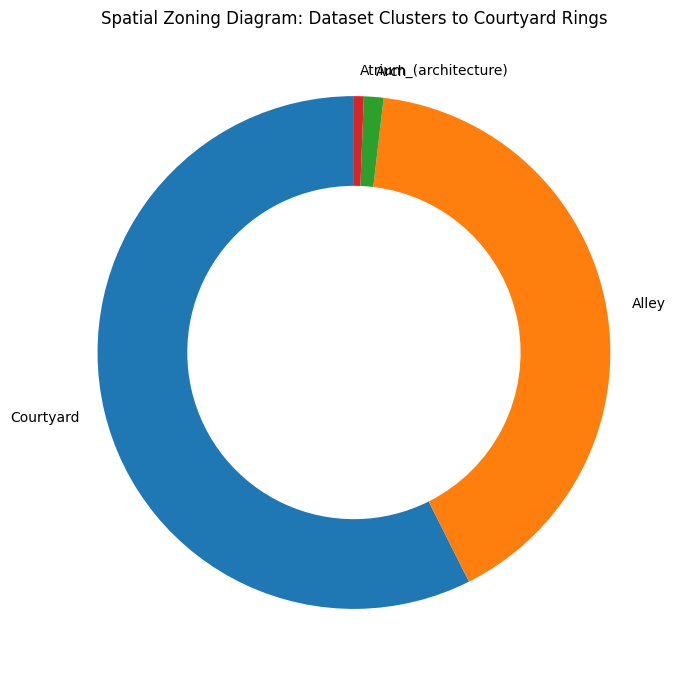

In [7]:
if page_col in df_match.columns:
    zones = df_match[page_col].fillna("Other").astype(str).value_counts().head(4)
else:
    zones = pd.Series({"Courtyard": 40, "Alley": 35, "Arch": 30, "Other": 20})

sizes = zones.values
labels = zones.index

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, startangle=90, wedgeprops=dict(width=0.35))
plt.title("Spatial Zoning Diagram: Dataset Clusters to Courtyard Rings")
plt.tight_layout()
plt.savefig(out_dir / "06_courtyard_zoning_diagram.png", dpi=300)
plt.show()

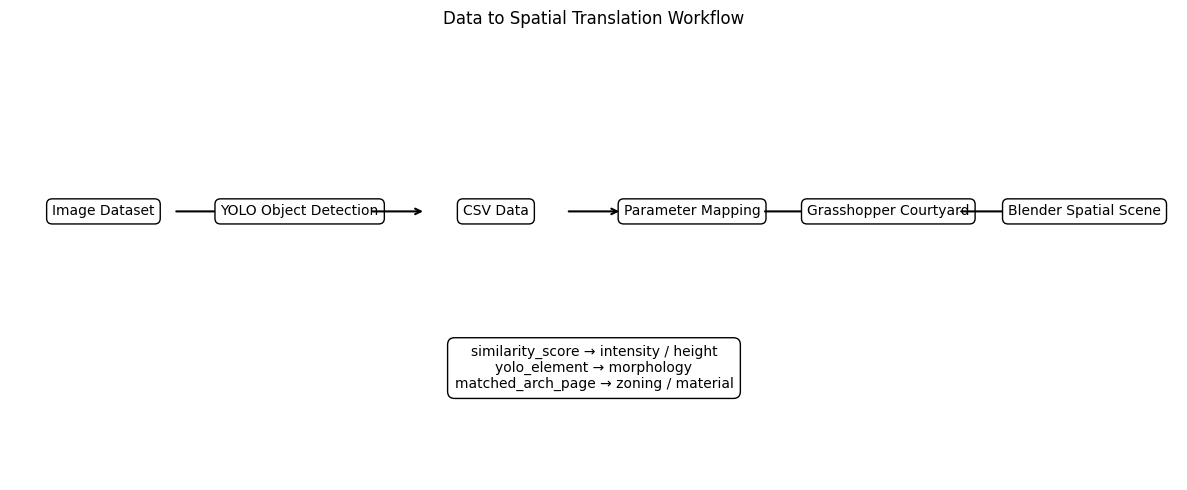

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

steps = [
    "Image Dataset",
    "YOLO Object Detection",
    "CSV Data",
    "Parameter Mapping",
    "Grasshopper Courtyard",
    "Blender Spatial Scene"
]

x_positions = np.linspace(0.08, 0.92, len(steps))

for i, (x, step) in enumerate(zip(x_positions, steps)):
    ax.text(x, 0.6, step, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"))
    if i < len(steps) - 1:
        ax.annotate("", xy=(x_positions[i+1]-0.06, 0.6), xytext=(x+0.06, 0.6),
                    arrowprops=dict(arrowstyle="->", lw=1.5))

ax.text(0.5, 0.25,
        "similarity_score → intensity / height\n"
        "yolo_element → morphology\n"
        "matched_arch_page → zoning / material",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black"))

plt.title("Data to Spatial Translation Workflow")
plt.tight_layout()
plt.savefig(out_dir / "07_data_to_space_pipeline.png", dpi=300)
plt.show()

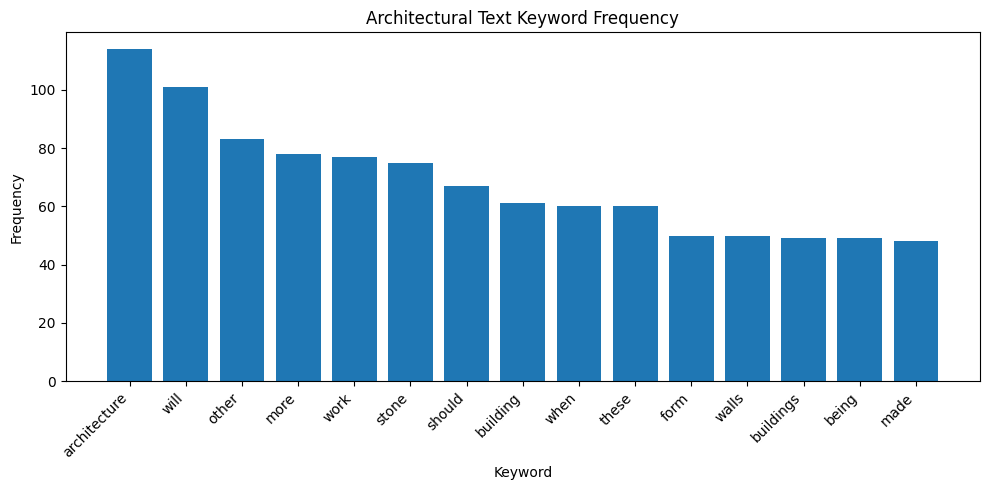

In [9]:
text_col = "text"

if text_col in df_text.columns:
    all_text = " ".join(df_text[text_col].dropna().astype(str).tolist()).lower()
    words = re.findall(r"\b[a-z]{4,}\b", all_text)

    stopwords = {
        "that", "with", "this", "from", "were", "have", "which", "their",
        "there", "shall", "would", "could", "upon", "been", "they", "them",
        "into", "than", "also", "such", "only"
    }

    words = [w for w in words if w not in stopwords]
    freq = Counter(words).most_common(15)

    labels = [x[0] for x in freq]
    values = [x[1] for x in freq]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Architectural Text Keyword Frequency")
    plt.xlabel("Keyword")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(out_dir / "08_text_keyword_frequency.png", dpi=300)
    plt.show()
else:
    print("No text column found.")

In [10]:
print("All figures saved to:")
print(out_dir)
print(list(out_dir.glob("*.png")))

All figures saved to:
C:\Users\16598\workshop_final\part1_analysis_figures
[WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/01_object_frequency.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/02_similarity_distribution.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/03_arch_reference_distribution.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/04_similarity_to_height_mapping.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/05_object_to_morphology_mapping.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/06_courtyard_zoning_diagram.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/07_data_to_space_pipeline.png'), WindowsPath('C:/Users/16598/workshop_final/part1_analysis_figures/08_text_keyword_frequency.png')]


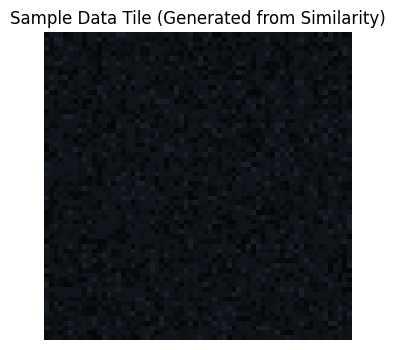

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 用 similarity_score 生成一个像素纹理
score_col = "similarity_score" if "similarity_score" in df_match.columns else df_match.columns[0]
scores = pd.to_numeric(df_match[score_col], errors="coerce").dropna()

# 生成 64x64 像素图
size = 64
tile = np.zeros((size, size, 3))

# 填充像素
for i in range(size):
    for j in range(size):
        val = np.random.choice(scores)

        # 转换成 RGB（你可以调风格）
        tile[i, j, 0] = val * 0.6   # R
        tile[i, j, 1] = val * 0.8   # G
        tile[i, j, 2] = val * 1.0   # B

plt.figure(figsize=(4,4))
plt.imshow(tile)
plt.title("Sample Data Tile (Generated from Similarity)")
plt.axis("off")

plt.savefig(out_dir / "sample_data_tile.png", dpi=300)
plt.show()

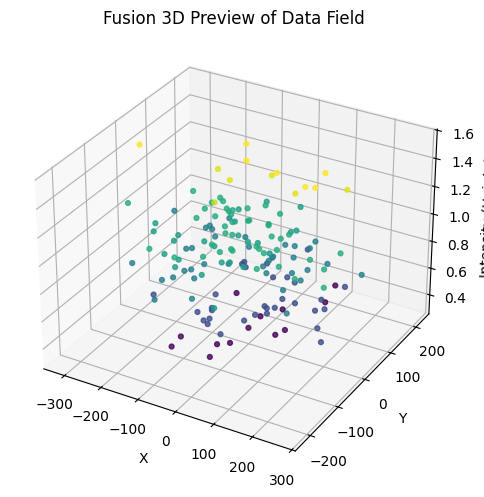

In [12]:
from mpl_toolkits.mplot3d import Axes3D

# 取数据
scores = pd.to_numeric(df_match[score_col], errors="coerce").dropna()

n = len(scores)

# 生成空间坐标
x = np.random.normal(0, 120, n)
y = np.random.normal(0, 80, n)
z = scores * 10   # similarity → height

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, c=z, s=12, alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Intensity (Height)")

ax.set_title("Fusion 3D Preview of Data Field")

plt.tight_layout()
plt.savefig(out_dir / "fusion_3d_preview.png", dpi=300)
plt.show()

YOLO: (162, 16)
MATCH: (162, 6)
TEXT: (300, 7)
Figures will be saved to: C:\Users\16598\workshop_final\report_figures


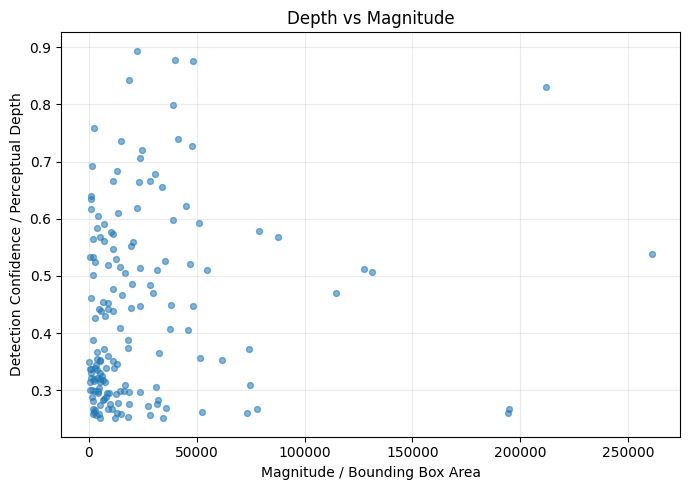

saved: C:\Users\16598\workshop_final\report_figures\07_depth_vs_magnitude.png


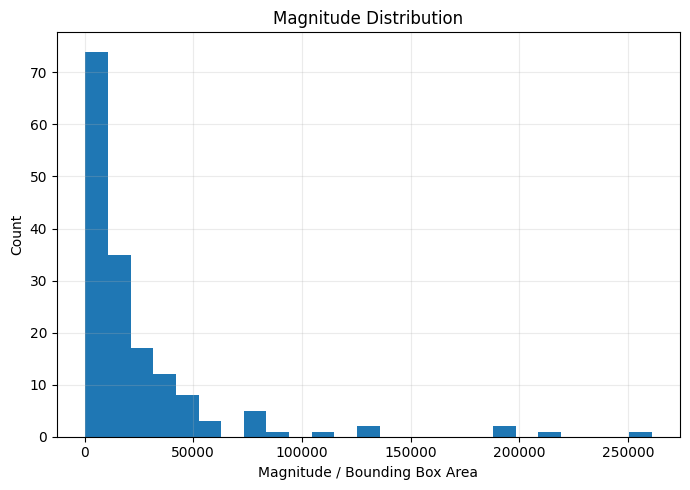

saved: C:\Users\16598\workshop_final\report_figures\08_magnitude_distribution.png


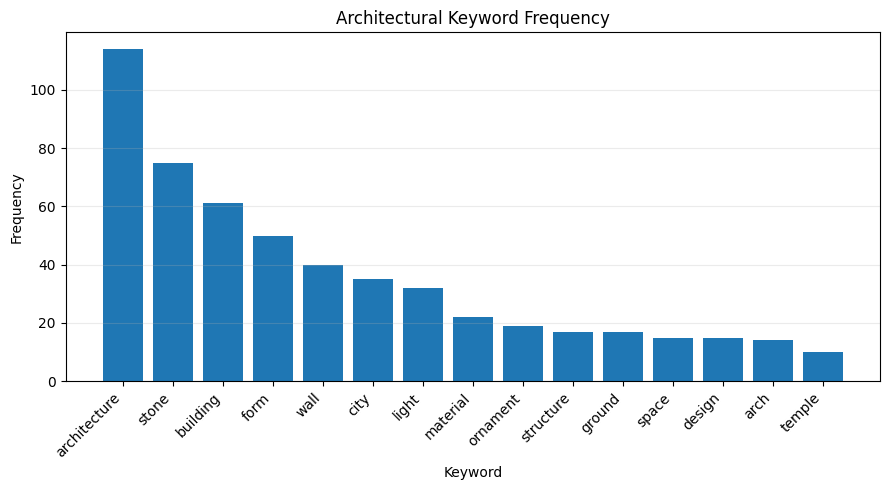

saved: C:\Users\16598\workshop_final\report_figures\09_keyword_frequency.png


C:\Users\16598\AppData\Local\Temp\ipykernel_16408\3267715620.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=page_order, showfliers=False)


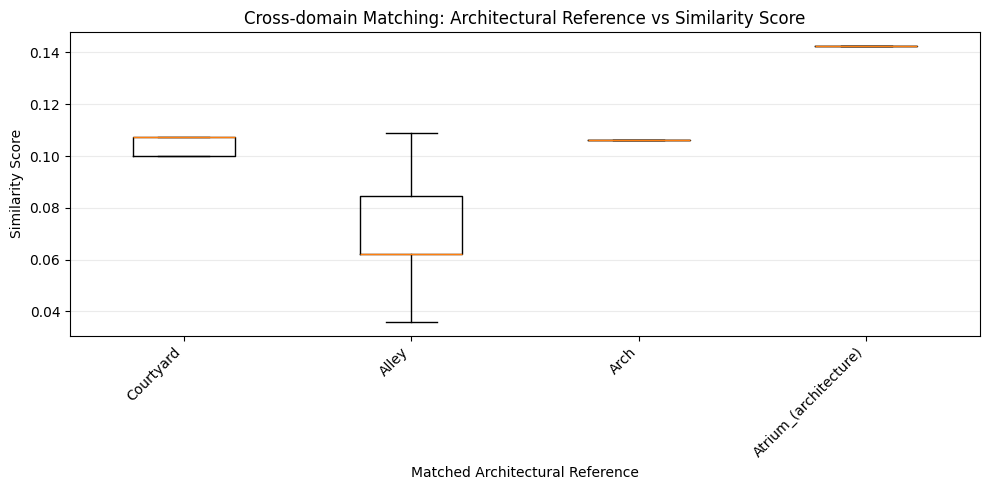

saved: C:\Users\16598\workshop_final\report_figures\10_cross_domain_matching.png


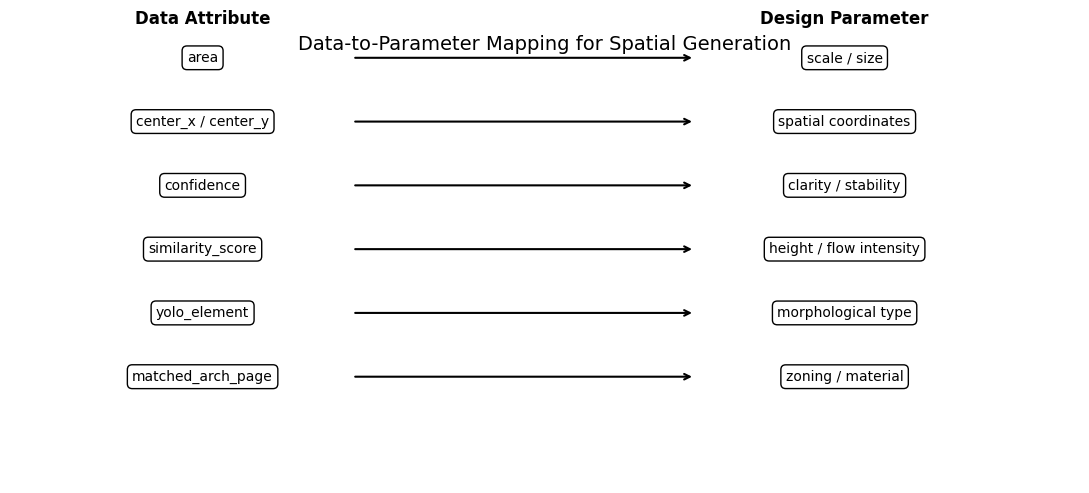

saved: C:\Users\16598\workshop_final\report_figures\11_data_to_parameter_mapping.png

DONE. Generated figures:
C:\Users\16598\workshop_final\report_figures\07_depth_vs_magnitude.png
C:\Users\16598\workshop_final\report_figures\08_magnitude_distribution.png
C:\Users\16598\workshop_final\report_figures\09_keyword_frequency.png
C:\Users\16598\workshop_final\report_figures\10_cross_domain_matching.png
C:\Users\16598\workshop_final\report_figures\11_data_to_parameter_mapping.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import re

# =========================
# Paths
# =========================
BASE = Path(r"C:\Users\16598\workshop_final")
OUT = BASE / "report_figures"
OUT.mkdir(parents=True, exist_ok=True)

yolo_csv = BASE / "dataset_2_yolo_spatial_elements_clean.csv"
match_csv = BASE / "dataset_4_spatial_matching_improved.csv"
text_csv = BASE / "dataset_4_architecture_treatise_text.csv"

df_yolo = pd.read_csv(yolo_csv)
df_match = pd.read_csv(match_csv)
df_text = pd.read_csv(text_csv)

print("YOLO:", df_yolo.shape)
print("MATCH:", df_match.shape)
print("TEXT:", df_text.shape)
print("Figures will be saved to:", OUT)

# =========================
# Helper
# =========================
def save_fig(name):
    plt.tight_layout()
    path = OUT / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("saved:", path)

# =========================
# Figure 7: Depth vs Magnitude
# 用 bbox area 作为 magnitude，用 confidence / similarity 作为 depth-like intensity
# =========================
area_col = "area" if "area" in df_yolo.columns else None
conf_col = "conf" if "conf" in df_yolo.columns else None

if area_col and conf_col:
    area = pd.to_numeric(df_yolo[area_col], errors="coerce")
    conf = pd.to_numeric(df_yolo[conf_col], errors="coerce")

    valid = area.notna() & conf.notna()
    magnitude = area[valid]
    depth = conf[valid]

    plt.figure(figsize=(7, 5))
    plt.scatter(magnitude, depth, s=18, alpha=0.55)
    plt.title("Depth vs Magnitude")
    plt.xlabel("Magnitude / Bounding Box Area")
    plt.ylabel("Detection Confidence / Perceptual Depth")
    plt.grid(alpha=0.25)
    save_fig("07_depth_vs_magnitude.png")
else:
    print("Cannot make depth_vs_magnitude: missing area/conf columns")

# =========================
# Figure 8: Magnitude Distribution
# =========================
if area_col:
    magnitude = pd.to_numeric(df_yolo[area_col], errors="coerce").dropna()

    plt.figure(figsize=(7, 5))
    plt.hist(magnitude, bins=25)
    plt.title("Magnitude Distribution")
    plt.xlabel("Magnitude / Bounding Box Area")
    plt.ylabel("Count")
    plt.grid(alpha=0.25)
    save_fig("08_magnitude_distribution.png")
else:
    print("Cannot make magnitude_distribution: missing area column")

# =========================
# Figure 9: Keyword Frequency
# 从 architecture treatise text 里提取建筑关键词
# =========================
text_col = "text" if "text" in df_text.columns else df_text.columns[-1]

all_text = " ".join(df_text[text_col].dropna().astype(str).tolist()).lower()
words = re.findall(r"\b[a-z]{4,}\b", all_text)

stopwords = {
    "that", "with", "this", "from", "were", "have", "which", "their",
    "there", "shall", "would", "could", "upon", "been", "they", "them",
    "into", "than", "also", "such", "only", "when", "where", "what",
    "will", "more", "very", "some", "then", "than", "made", "much"
}

arch_keywords = [
    "architecture", "building", "space", "wall", "stone", "light",
    "column", "arch", "form", "structure", "temple", "house",
    "ornament", "proportion", "street", "city", "passage",
    "court", "material", "design", "surface", "height", "door",
    "window", "ground", "roof"
]

filtered = [w for w in words if w not in stopwords]
counter = Counter(filtered)

keyword_counts = [(k, counter[k]) for k in arch_keywords if counter[k] > 0]
keyword_counts = sorted(keyword_counts, key=lambda x: x[1], reverse=True)[:15]

labels = [k for k, v in keyword_counts]
values = [v for k, v in keyword_counts]

plt.figure(figsize=(9, 5))
plt.bar(labels, values)
plt.title("Architectural Keyword Frequency")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
save_fig("09_keyword_frequency.png")

# =========================
# Figure 10: Cross-domain Matching Preview
# 用 matched_arch_page + similarity_score 可视化
# =========================
if "matched_arch_page" in df_match.columns and "similarity_score" in df_match.columns:
    temp = df_match.copy()
    temp["similarity_score"] = pd.to_numeric(temp["similarity_score"], errors="coerce")
    temp = temp.dropna(subset=["similarity_score"])

    page_order = temp["matched_arch_page"].value_counts().head(8).index
    temp = temp[temp["matched_arch_page"].isin(page_order)]

    plt.figure(figsize=(10, 5))
    data = [temp[temp["matched_arch_page"] == p]["similarity_score"] for p in page_order]
    plt.boxplot(data, labels=page_order, showfliers=False)
    plt.title("Cross-domain Matching: Architectural Reference vs Similarity Score")
    plt.xlabel("Matched Architectural Reference")
    plt.ylabel("Similarity Score")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.25)
    save_fig("10_cross_domain_matching.png")
else:
    print("Cannot make matching plot: missing matched_arch_page/similarity_score")

# =========================
# Figure 11: Data-to-Parameter Mapping Diagram
# =========================
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis("off")

left = [
    "area",
    "center_x / center_y",
    "confidence",
    "similarity_score",
    "yolo_element",
    "matched_arch_page"
]

right = [
    "scale / size",
    "spatial coordinates",
    "clarity / stability",
    "height / flow intensity",
    "morphological type",
    "zoning / material"
]

for i, (l, r) in enumerate(zip(left, right)):
    y = 1 - i * 0.15

    ax.text(0.18, y, l, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"))

    ax.text(0.78, y, r, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"))

    ax.annotate(
        "",
        xy=(0.64, y),
        xytext=(0.32, y),
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.text(0.18, 1.08, "Data Attribute", ha="center", fontsize=12, weight="bold")
ax.text(0.78, 1.08, "Design Parameter", ha="center", fontsize=12, weight="bold")
ax.set_title("Data-to-Parameter Mapping for Spatial Generation", fontsize=14)

save_fig("11_data_to_parameter_mapping.png")

print("\nDONE. Generated figures:")
for p in sorted(OUT.glob("*.png")):
    print(p)

YOLO columns: ['source_image', 'obj_id', 'spatial_element', 'conf', 'x1', 'y1', 'x2', 'y2', 'width', 'height', 'area', 'center_x', 'center_y', 'mask_path', 'crop_path', 'annotated_path']
MATCH columns: ['source_image', 'yolo_element', 'spatial_description', 'matched_arch_page', 'matched_arch_text', 'similarity_score']


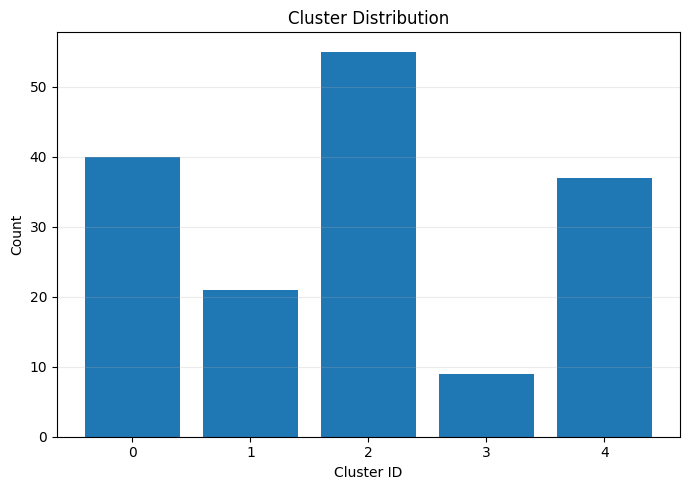

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\cluster_distribution.png


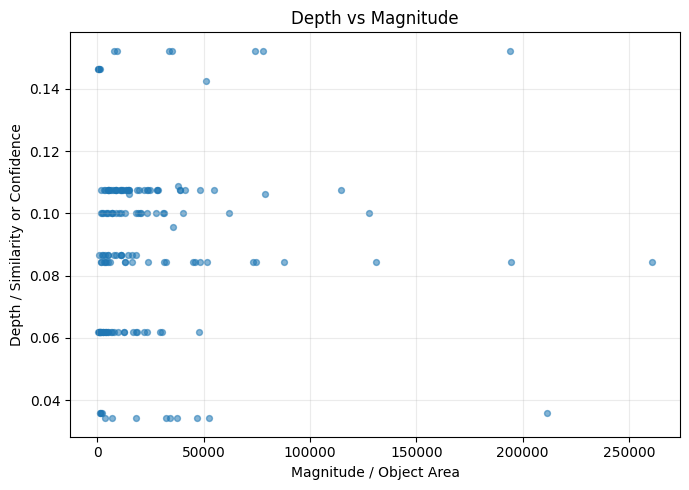

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\depth_vs_magnitude.png


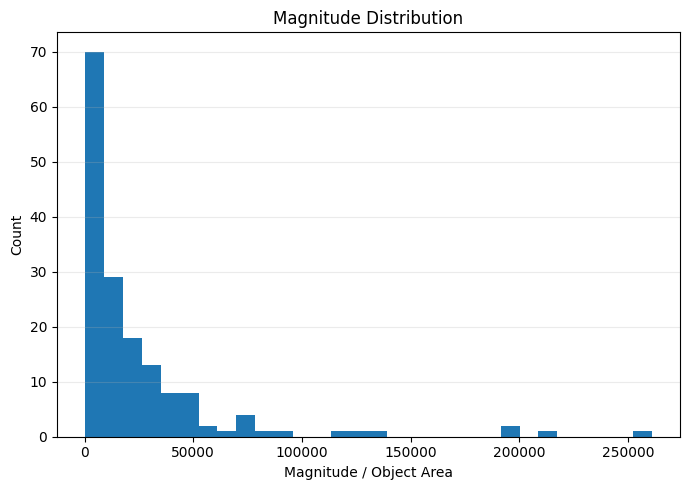

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\magnitude_distribution.png


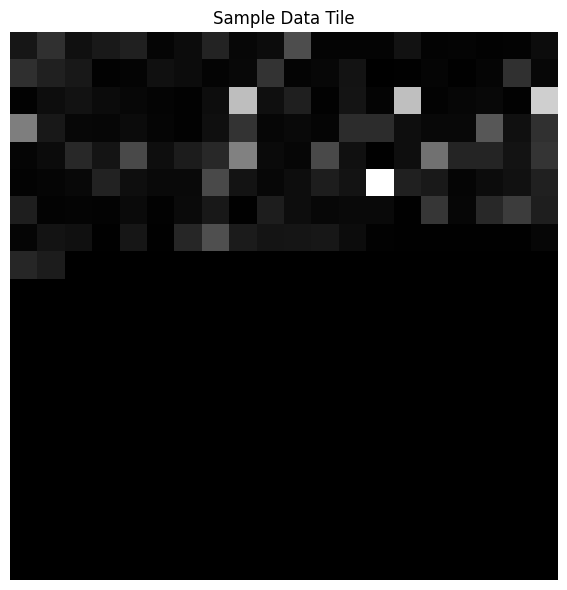

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\sample_data_tile.png

DONE. Generated files:
C:\Users\16598\workshop_final\part1_analysis_figures\cluster_distribution.png
C:\Users\16598\workshop_final\part1_analysis_figures\depth_vs_magnitude.png
C:\Users\16598\workshop_final\part1_analysis_figures\magnitude_distribution.png
C:\Users\16598\workshop_final\part1_analysis_figures\sample_data_tile.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =========================
# Paths
# =========================
BASE = Path(r"C:\Users\16598\workshop_final")
OUT = BASE / "part1_analysis_figures"
OUT.mkdir(parents=True, exist_ok=True)

yolo_csv = BASE / "dataset_2_yolo_spatial_elements_clean.csv"
match_csv = BASE / "dataset_4_spatial_matching_improved.csv"

df_yolo = pd.read_csv(yolo_csv)
df_match = pd.read_csv(match_csv)

print("YOLO columns:", df_yolo.columns.tolist())
print("MATCH columns:", df_match.columns.tolist())

# =========================
# Helper
# =========================
def save_fig(filename):
    path = OUT / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# =========================
# 1. Cluster Distribution
# =========================
# 自动找可用数值列
possible_cols = ["x1", "y1", "x2", "y2", "width", "height", "area", "center_x", "center_y", "conf"]
feature_cols = [c for c in possible_cols if c in df_yolo.columns]

if len(feature_cols) < 2:
    raise ValueError("Not enough numeric columns for clustering. Check CSV column names.")

X = df_yolo[feature_cols].apply(pd.to_numeric, errors="coerce").dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_counts = pd.Series(clusters).value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Cluster Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
save_fig("cluster_distribution.png")

# =========================
# 2. Depth vs Magnitude
# =========================
# magnitude 优先用 area，没有就用 width*height
if "area" in df_yolo.columns:
    magnitude = pd.to_numeric(df_yolo["area"], errors="coerce")
elif "width" in df_yolo.columns and "height" in df_yolo.columns:
    magnitude = pd.to_numeric(df_yolo["width"], errors="coerce") * pd.to_numeric(df_yolo["height"], errors="coerce")
else:
    raise ValueError("Cannot find area or width/height columns.")

# depth 优先用 similarity_score，其次 conf
if "similarity_score" in df_match.columns:
    depth = pd.to_numeric(df_match["similarity_score"], errors="coerce")
    min_len = min(len(magnitude), len(depth))
    magnitude_plot = magnitude.iloc[:min_len]
    depth_plot = depth.iloc[:min_len]
elif "conf" in df_yolo.columns:
    depth_plot = pd.to_numeric(df_yolo["conf"], errors="coerce")
    magnitude_plot = magnitude
else:
    raise ValueError("Cannot find similarity_score or conf column.")

valid = magnitude_plot.notna() & depth_plot.notna()

plt.figure(figsize=(7, 5))
plt.scatter(magnitude_plot[valid], depth_plot[valid], s=18, alpha=0.55)
plt.title("Depth vs Magnitude")
plt.xlabel("Magnitude / Object Area")
plt.ylabel("Depth / Similarity or Confidence")
plt.grid(alpha=0.25)
save_fig("depth_vs_magnitude.png")

# =========================
# 3. Magnitude Distribution
# =========================
mag = magnitude.dropna()

plt.figure(figsize=(7, 5))
plt.hist(mag, bins=30)
plt.title("Magnitude Distribution")
plt.xlabel("Magnitude / Object Area")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
save_fig("magnitude_distribution.png")

# =========================
# 4. Sample Data Tile
# =========================
# 用 YOLO 数值列生成一个“数据瓦片”，不是原始图片，而是数据矩阵可视化
tile_cols = [c for c in ["conf", "area", "center_x", "center_y", "width", "height"] if c in df_yolo.columns]

if len(tile_cols) < 2:
    tile_cols = feature_cols[:min(6, len(feature_cols))]

tile_data = df_yolo[tile_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# 取前 400 行，归一化后变成 20x20 数据图
values = tile_data.mean(axis=1).values
values = values[:400]

if len(values) < 400:
    values = np.pad(values, (0, 400 - len(values)), mode="constant")

values = values.reshape(20, 20)

# normalize
values = (values - values.min()) / (values.max() - values.min() + 1e-9)

plt.figure(figsize=(6, 6))
plt.imshow(values, cmap="gray")
plt.title("Sample Data Tile")
plt.axis("off")
save_fig("sample_data_tile.png")

print("\nDONE. Generated files:")
for f in [
    "cluster_distribution.png",
    "depth_vs_magnitude.png",
    "magnitude_distribution.png",
    "sample_data_tile.png"
]:
    print(OUT / f)

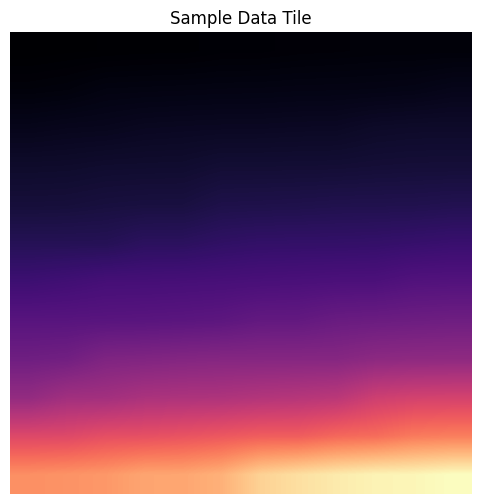

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\sample_data_tile_clean.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path(r"C:\Users\16598\workshop_final")
OUT = BASE / "part1_analysis_figures"
OUT.mkdir(parents=True, exist_ok=True)

yolo_csv = BASE / "dataset_2_yolo_spatial_elements_clean.csv"
df = pd.read_csv(yolo_csv)

cols = [c for c in ["conf", "area", "center_x", "center_y", "width", "height"] if c in df.columns]
if len(cols) < 2:
    cols = df.select_dtypes(include="number").columns.tolist()[:6]

data = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

# 每一行合成为一个强度值
values = data.mean(axis=1).values

# 排序，让图像更像连续数据场，而不是随机噪点
values = np.sort(values)

# 只取能组成完整正方形的数量
n = int(np.sqrt(len(values)))
values = values[:n*n].reshape(n, n)

# 归一化
values = (values - values.min()) / (values.max() - values.min() + 1e-9)

plt.figure(figsize=(6, 6))
plt.imshow(values, cmap="magma", interpolation="bilinear")
plt.title("Sample Data Tile")
plt.axis("off")

path = OUT / "sample_data_tile_clean.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)

Index(['dataset', 'source', 'title', 'author', 'url', 'text', 'word_count'], dtype='str')
                      dataset             source  \
0  architecture_treatise_text  Project Gutenberg   
1  architecture_treatise_text  Project Gutenberg   
2  architecture_treatise_text  Project Gutenberg   
3  architecture_treatise_text  Project Gutenberg   
4  architecture_treatise_text  Project Gutenberg   

                           title            author  \
0  The Ten Books on Architecture  Vitruvius Pollio   
1  The Ten Books on Architecture  Vitruvius Pollio   
2  The Ten Books on Architecture  Vitruvius Pollio   
3  The Ten Books on Architecture  Vitruvius Pollio   
4  The Ten Books on Architecture  Vitruvius Pollio   

                                               url  \
0  https://www.gutenberg.org/files/20239/20239.txt   
1  https://www.gutenberg.org/files/20239/20239.txt   
2  https://www.gutenberg.org/files/20239/20239.txt   
3  https://www.gutenberg.org/files/20239/20239.txt   
4 

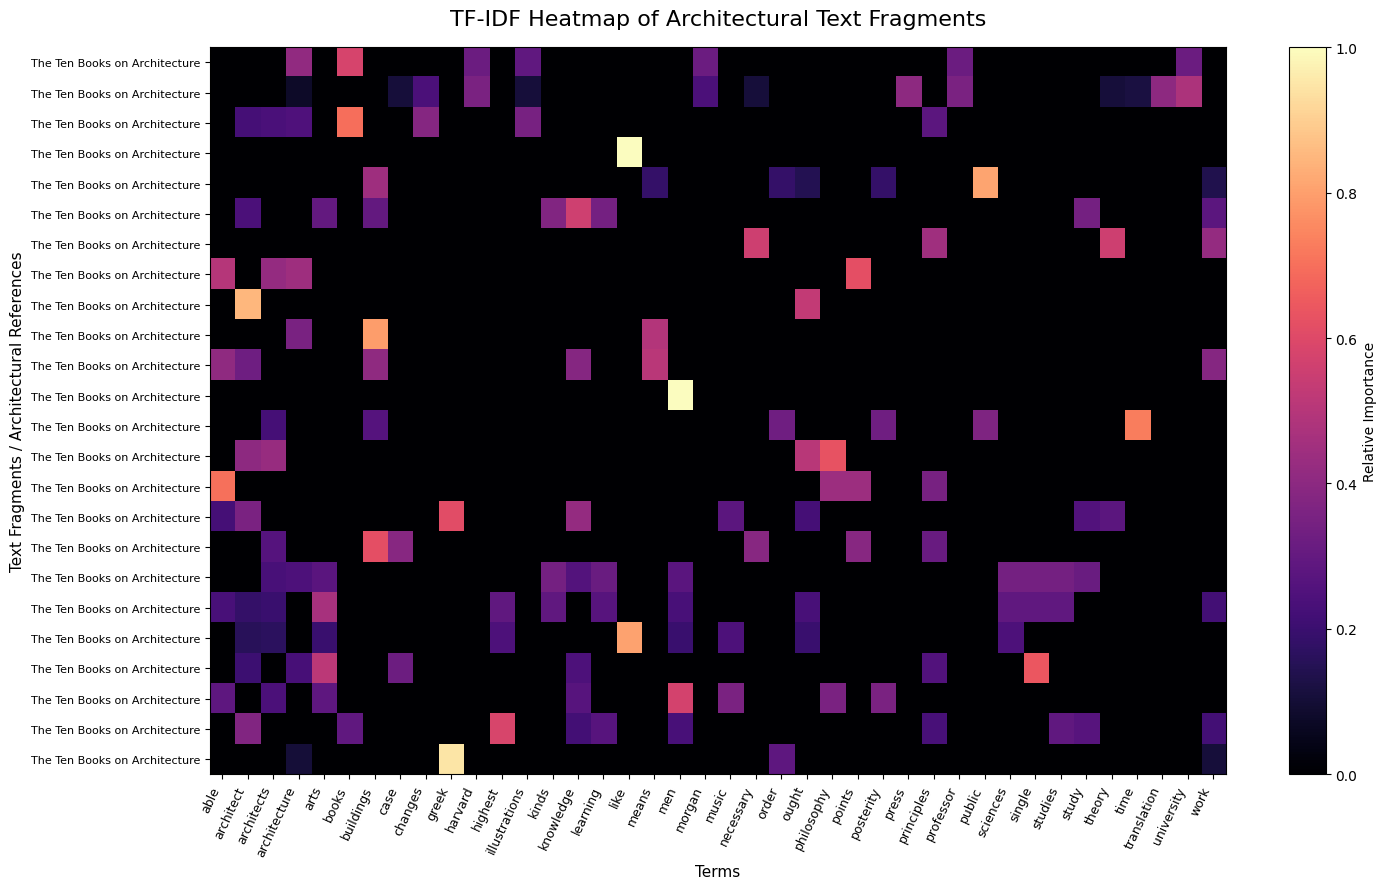

Saved: C:\Users\16598\workshop_final\part1_analysis_figures\09_tfidf_heatmap_architectural_text.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# =========================
# Paths
# =========================
BASE = Path(r"C:\Users\16598\workshop_final")
OUT = BASE / "part1_analysis_figures"
OUT.mkdir(parents=True, exist_ok=True)

text_csv = BASE / "dataset_4_architecture_treatise_text.csv"
df = pd.read_csv(text_csv)

print(df.columns)
print(df.head())

# =========================
# Pick text column automatically
# =========================
possible_text_cols = ["text", "content", "sentence", "paragraph", "page_text"]
text_col = None

for c in possible_text_cols:
    if c in df.columns:
        text_col = c
        break

if text_col is None:
    # 自动选最长文本列
    text_col = max(df.columns, key=lambda c: df[c].astype(str).str.len().mean())

print("Using text column:", text_col)

texts = df[text_col].dropna().astype(str).tolist()

# 只取前 24 条，做成类似参考图那种结构
texts = texts[:24]

# 如果有 page / title / source 列，就用作 y 轴标签
label_col = None
for c in ["page", "title", "source", "location", "chapter"]:
    if c in df.columns:
        label_col = c
        break

if label_col:
    y_labels = df[label_col].astype(str).tolist()[:24]
else:
    y_labels = [f"Text Fragment {i+1}" for i in range(len(texts))]

# =========================
# TF-IDF
# =========================
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=40,
    min_df=1,
    max_df=0.85
)

tfidf = vectorizer.fit_transform(texts)
terms = vectorizer.get_feature_names_out()
matrix = tfidf.toarray()

# 删除全 0 列
nonzero_cols = matrix.sum(axis=0) > 0
matrix = matrix[:, nonzero_cols]
terms = terms[nonzero_cols]

# =========================
# Plot
# =========================
plt.figure(figsize=(15, 9))

plt.imshow(matrix, aspect="auto", cmap="magma", interpolation="nearest")

plt.title("TF-IDF Heatmap of Architectural Text Fragments", fontsize=16, pad=16)
plt.xlabel("Terms", fontsize=11)
plt.ylabel("Text Fragments / Architectural References", fontsize=11)

plt.xticks(
    ticks=np.arange(len(terms)),
    labels=terms,
    rotation=65,
    ha="right",
    fontsize=9
)

plt.yticks(
    ticks=np.arange(len(y_labels)),
    labels=y_labels,
    fontsize=8
)

cbar = plt.colorbar()
cbar.set_label("Relative Importance", rotation=90)

plt.tight_layout()

path = OUT / "09_tfidf_heatmap_architectural_text.png"
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)